# Seasonal Agriculture Performance Analysis


## Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset

In [8]:
def load_dataset(filepath: str) -> pd.DataFrame:
   
    data = pd.read_csv(filepath)
    return data


# Load the raw dataset
df = load_dataset('seasonal_agriculture_performance_dataset.csv')
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## Explore Dataset

In [9]:
def explore_dataset(data: pd.DataFrame) -> None:
   
    print('Shape (rows, columns):', data.shape)
    print('\nColumn Names:\n', data.columns.tolist())
    print('\nData Types:\n', data.dtypes)


explore_dataset(df)


Shape (rows, columns): (4000, 28)

Column Names:
 ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:
 Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH          

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## Data Quality Check

In [11]:
def check_duplicates(data: pd.DataFrame) -> int:
    
    duplicate_count = data.duplicated().sum()
    print(f'Duplicate rows found: {duplicate_count}')
    return duplicate_count


def check_missing_values(data: pd.DataFrame) -> pd.DataFrame:
    
    missing = pd.DataFrame({
        'Missing Count': data.isna().sum(),
        'Missing %': (data.isna().mean() * 100).round(2)
    })
    missing = missing[missing['Missing Count'] > 0]
    return missing.sort_values('Missing Count', ascending=False)


check_duplicates(df)
check_missing_values(df)


Duplicate rows found: 0


,Missing Count,Missing %
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [12]:

def detect_outliers_iqr(data: pd.DataFrame, columns: list) -> pd.DataFrame:
   
    summary_rows = []
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_count = data[(data[col] < lower) | (data[col] > upper)].shape[0]
        summary_rows.append({
            'Column': col,
            'Lower Bound': round(lower, 2),
            'Upper Bound': round(upper, 2),
            'Outlier Count': outlier_count
        })
    return pd.DataFrame(summary_rows)


numeric_cols_to_check = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3',
                          'Production_Tonnes', 'Rainfall_mm']
detect_outliers_iqr(df, numeric_cols_to_check)



,Column,Lower Bound,Upper Bound,Outlier Count
0,Yield_Tonnes_Ha,-1.63,5.52,302
1,Profit_INR,-696111.00,763567.00,404
2,Water_Efficiency_t_per_1000m3,-3.57,10.38,322
3,Production_Tonnes,-23.98,53.36,333
4,Rainfall_mm,-326.93,1532.08,0


## Data Cleaning & Preparation

In [13]:
def handle_missing_values(data: pd.DataFrame) -> pd.DataFrame:
   
    cleaned = data.copy()
    cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

    for col in cols_to_impute:
        cleaned[col] = cleaned.groupby(['Season', 'Crop'])[col].transform(
            lambda s: s.fillna(s.median())
        )
        
        cleaned[col] = cleaned[col].fillna(cleaned[col].median())

    return cleaned


df_clean = handle_missing_values(df)

# Verify no missing values remain
check_missing_values(df_clean)


,Missing Count,Missing %


## Seasonal Summary Statistics

In [14]:
def add_derived_metrics(data: pd.DataFrame) -> pd.DataFrame:
   
    enriched = data.copy()
    enriched['Profit_Margin_pct'] = (enriched['Profit_INR'] / enriched['Revenue_INR']) * 100
    enriched['Cost_per_Tonne'] = enriched['Total_Cost_INR'] / enriched['Production_Tonnes']
    return enriched


df_clean = add_derived_metrics(df_clean)
df_clean[['Profit_Margin_pct', 'Cost_per_Tonne']].describe()


,Profit_Margin_pct,Cost_per_Tonne
count,4000.000000,4000.000000
mean,-45.492178,55624.858332
std,158.085472,54260.608703
min,-1461.851219,568.357511
25%,-60.192762,23032.641975
50%,1.146236,37897.601738
75%,32.885876,64153.096089
max,85.921220,296805.128205


In [15]:
def seasonal_summary_statistics(data: pd.DataFrame) -> pd.DataFrame:
   
    metrics = ['Yield_Tonnes_Ha', 'Rainfall_mm', 'Avg_Temperature_C',
               'Fertilizer_kg_ha', 'Water_Used_m3', 'Profit_INR',
               'Profit_Margin_pct', 'Disease_Pest_Risk_pct']
    summary = data.groupby('Season')[metrics].mean(numeric_only=True).round(2)
    return summary


seasonal_summary = seasonal_summary_statistics(df_clean)
seasonal_summary

,Yield_Tonnes_Ha,Rainfall_mm,Avg_Temperature_C,Fertilizer_kg_ha,Water_Used_m3,Profit_INR,Profit_Margin_pct,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,852.10,28.45,187.08,6102.20,178914.65,-38.64,54.47
Rabi,5.09,435.95,23.49,185.41,5846.99,87689.47,-44.27,40.48
Zaid,4.64,299.16,31.04,184.64,6419.89,-24804.82,-69.35,38.22


## Visual & Statistical Analysis

### Yield distribution across seasons

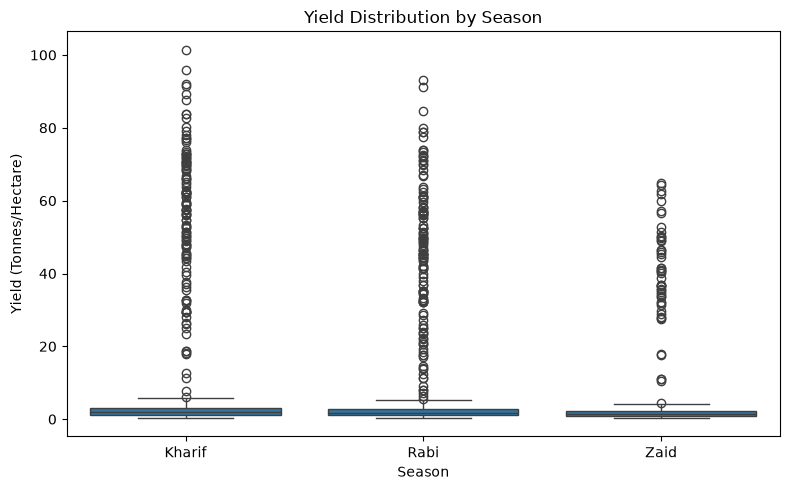

In [16]:
def plot_yield_by_season(data: pd.DataFrame) -> None:
    
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=data)
    plt.title('Yield Distribution by Season')
    plt.xlabel('Season')
    plt.ylabel('Yield (Tonnes/Hectare)')
    plt.tight_layout()
    plt.show()


plot_yield_by_season(df_clean)

### Environmental conditions by season

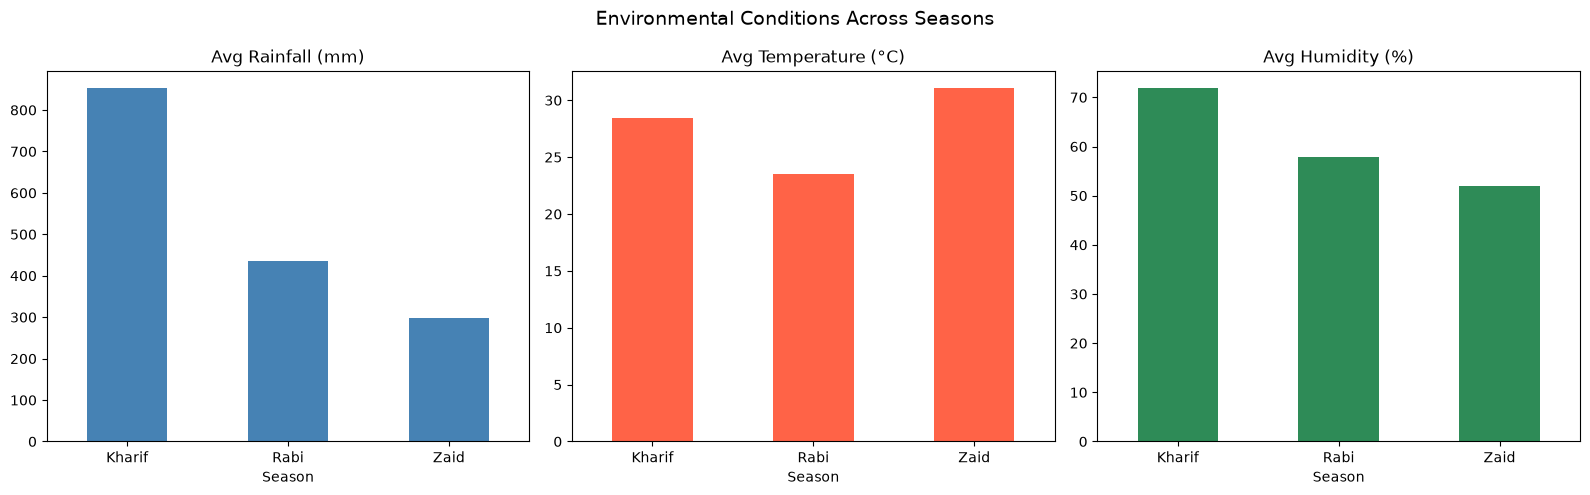

In [17]:
def plot_environmental_conditions_by_season(data: pd.DataFrame) -> None:
    
    env_avg = data.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']].mean()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    env_avg['Rainfall_mm'].plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Avg Rainfall (mm)')
    axes[0].set_xlabel('Season')
    axes[0].tick_params(axis='x', rotation=0)

    env_avg['Avg_Temperature_C'].plot(kind='bar', ax=axes[1], color='tomato')
    axes[1].set_title('Avg Temperature (°C)')
    axes[1].set_xlabel('Season')
    axes[1].tick_params(axis='x', rotation=0)

    env_avg['Humidity_pct'].plot(kind='bar', ax=axes[2], color='seagreen')
    axes[2].set_title('Avg Humidity (%)')
    axes[2].set_xlabel('Season')
    axes[2].tick_params(axis='x', rotation=0)

    fig.suptitle('Environmental Conditions Across Seasons', fontsize=14)
    plt.tight_layout()
    plt.show()


plot_environmental_conditions_by_season(df_clean)


### Resource usage by season

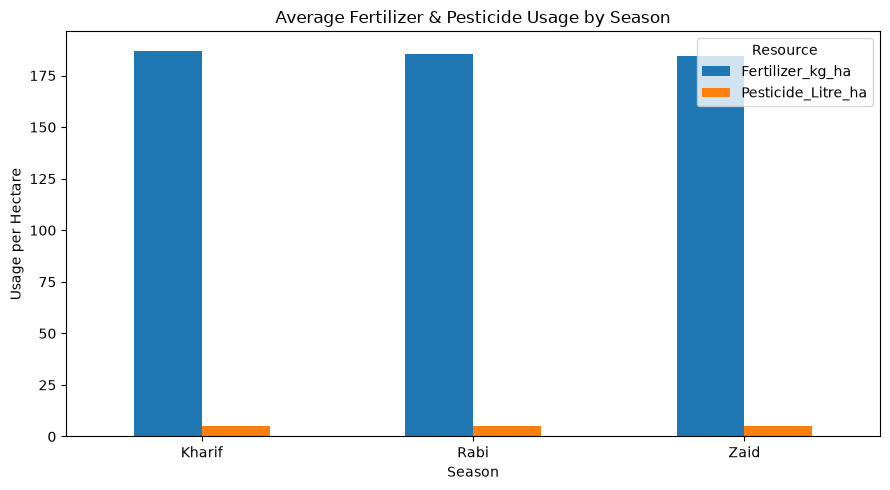

In [18]:
def plot_resource_usage_by_season(data: pd.DataFrame) -> None:
   
    resource_avg = data.groupby('Season')[
        ['Fertilizer_kg_ha', 'Pesticide_Litre_ha']
    ].mean()

    resource_avg.plot(kind='bar', figsize=(9, 5))
    plt.title('Average Fertilizer & Pesticide Usage by Season')
    plt.xlabel('Season')
    plt.ylabel('Usage per Hectare')
    plt.xticks(rotation=0)
    plt.legend(title='Resource')
    plt.tight_layout()
    plt.show()


plot_resource_usage_by_season(df_clean)


### Correlation between environmental & performance metrics

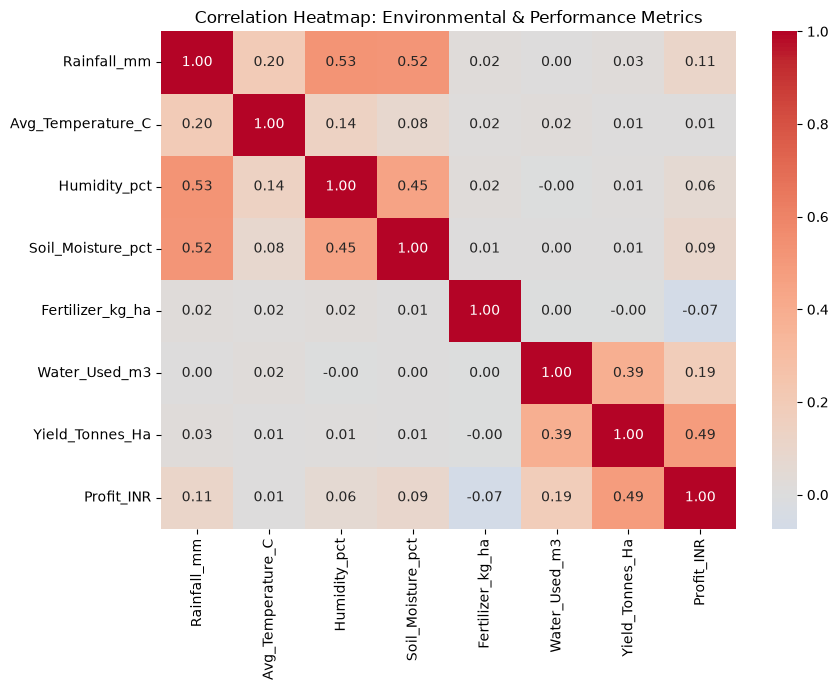

In [19]:
def plot_correlation_heatmap(data: pd.DataFrame) -> None:
   
    cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
            'Fertilizer_kg_ha', 'Water_Used_m3', 'Yield_Tonnes_Ha', 'Profit_INR']
    corr = data[cols].corr(numeric_only=True)

    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap: Environmental & Performance Metrics')
    plt.tight_layout()
    plt.show()


plot_correlation_heatmap(df_clean)



###  Crop distribution across seasons

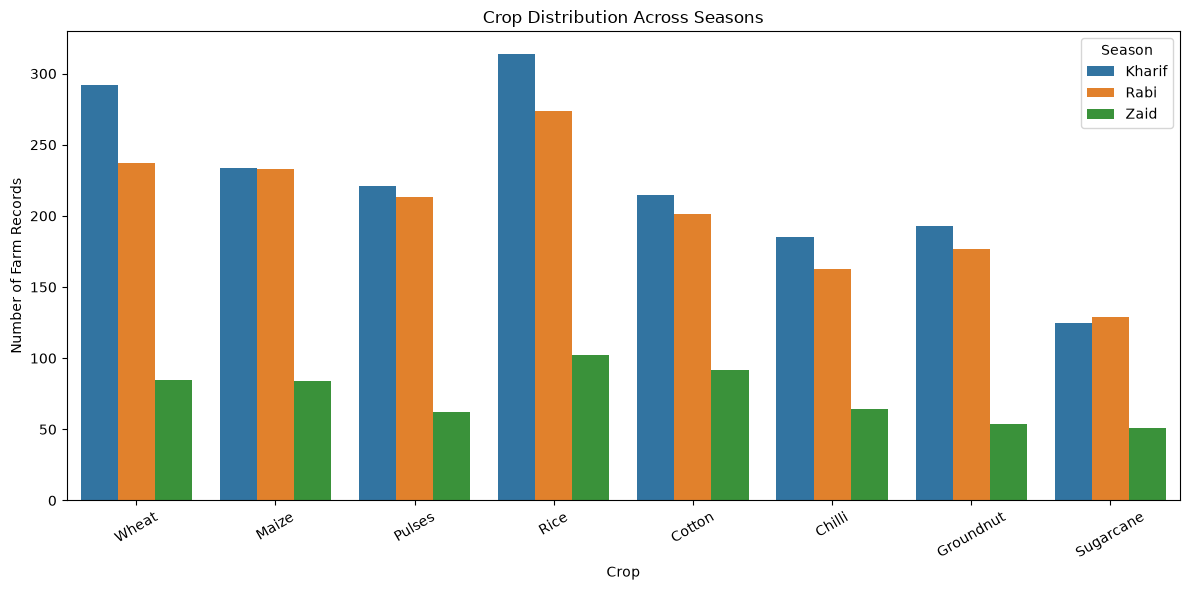

In [20]:
def plot_crop_distribution_by_season(data: pd.DataFrame) -> None:
   
    plt.figure(figsize=(12, 6))
    sns.countplot(x='Crop', hue='Season', data=data)
    plt.title('Crop Distribution Across Seasons')
    plt.xlabel('Crop')
    plt.ylabel('Number of Farm Records')
    plt.xticks(rotation=30)
    plt.legend(title='Season')
    plt.tight_layout()
    plt.show()


plot_crop_distribution_by_season(df_clean)


### State-wise seasonal yield performance

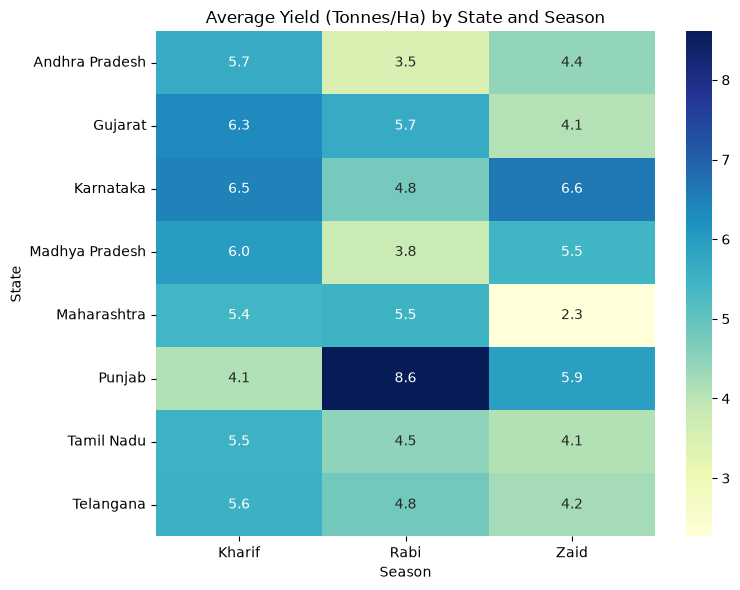

In [21]:
def plot_statewise_seasonal_yield(data: pd.DataFrame) -> None:
    
    pivot = data.pivot_table(values='Yield_Tonnes_Ha', index='State',
                              columns='Season', aggfunc='mean')

    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu')
    plt.title('Average Yield (Tonnes/Ha) by State and Season')
    plt.xlabel('Season')
    plt.ylabel('State')
    plt.tight_layout()
    plt.show()


plot_statewise_seasonal_yield(df_clean)


## Average Rainfall and Disease/Pest Risk by Season

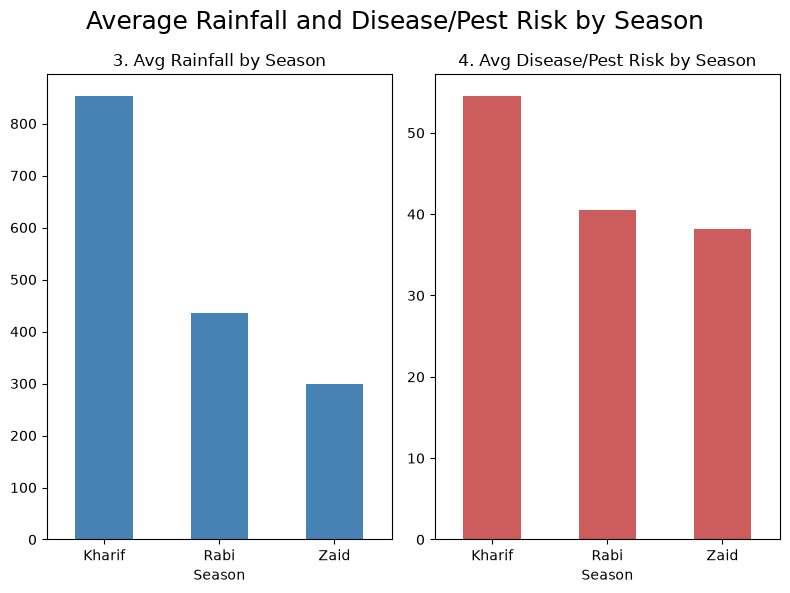

In [22]:
 
def plot_seasonal_dashboard(data: pd.DataFrame) -> None:
        
        fig, axes = plt.subplots(1, 2, figsize=(8, 6))
        fig.suptitle('Average Rainfall and Disease/Pest Risk by Season', fontsize=18)
        
        data.groupby('Season')['Rainfall_mm'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
        axes[0].set_title('3. Avg Rainfall by Season')
        axes[0].tick_params(axis='x', rotation=0)

        data.groupby('Season')['Disease_Pest_Risk_pct'].mean().plot(kind='bar', ax=axes[1], color='indianred')
        axes[1].set_title('4. Avg Disease/Pest Risk by Season')
        axes[1].tick_params(axis='x', rotation=0)

        plt.tight_layout()
        plt.show()

plot_seasonal_dashboard(df_clean)